In [2]:
import os
from pathlib import Path

from datasets import load_dataset, Audio, Image, Video

In [3]:
HF_PATH = "eturok-weizmann/my-laser-vibrations"

In [4]:
def get_hf_token() -> str:
    token_file = Path("~/.cache/huggingface/token").expanduser()
    if token_file.exists():
        return token_file.read_text().strip()
    raise RuntimeError("No local Hugging Face token found; run `huggingface-cli login` first")
HF_TOKEN = get_hf_token()
os.environ["HF_TOKEN"] = HF_TOKEN

In [24]:
# ds = load_dataset('eturok-weizmann/laser-vibrations-test')
ds = load_dataset("json", data_files="test-data/metadata.jsonl")
ds = ds.cast_column('overhead_image', Image())
ds = ds.cast_column('audio', Audio())
ds = ds.cast_column('speckle_vibration', Video())
ds.push_to_hub(HF_PATH)

Generating train split: 0 examples [00:00, ? examples/s]

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/eturok-weizmann/my-laser-vibrations/commit/5cd470d4d7cfd04a3932eefb1fd1ba5a860084f8', commit_message='Upload dataset', commit_description='', oid='5cd470d4d7cfd04a3932eefb1fd1ba5a860084f8', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/eturok-weizmann/my-laser-vibrations', endpoint='https://huggingface.co', repo_type='dataset', repo_id='eturok-weizmann/my-laser-vibrations'), pr_revision=None, pr_num=None)

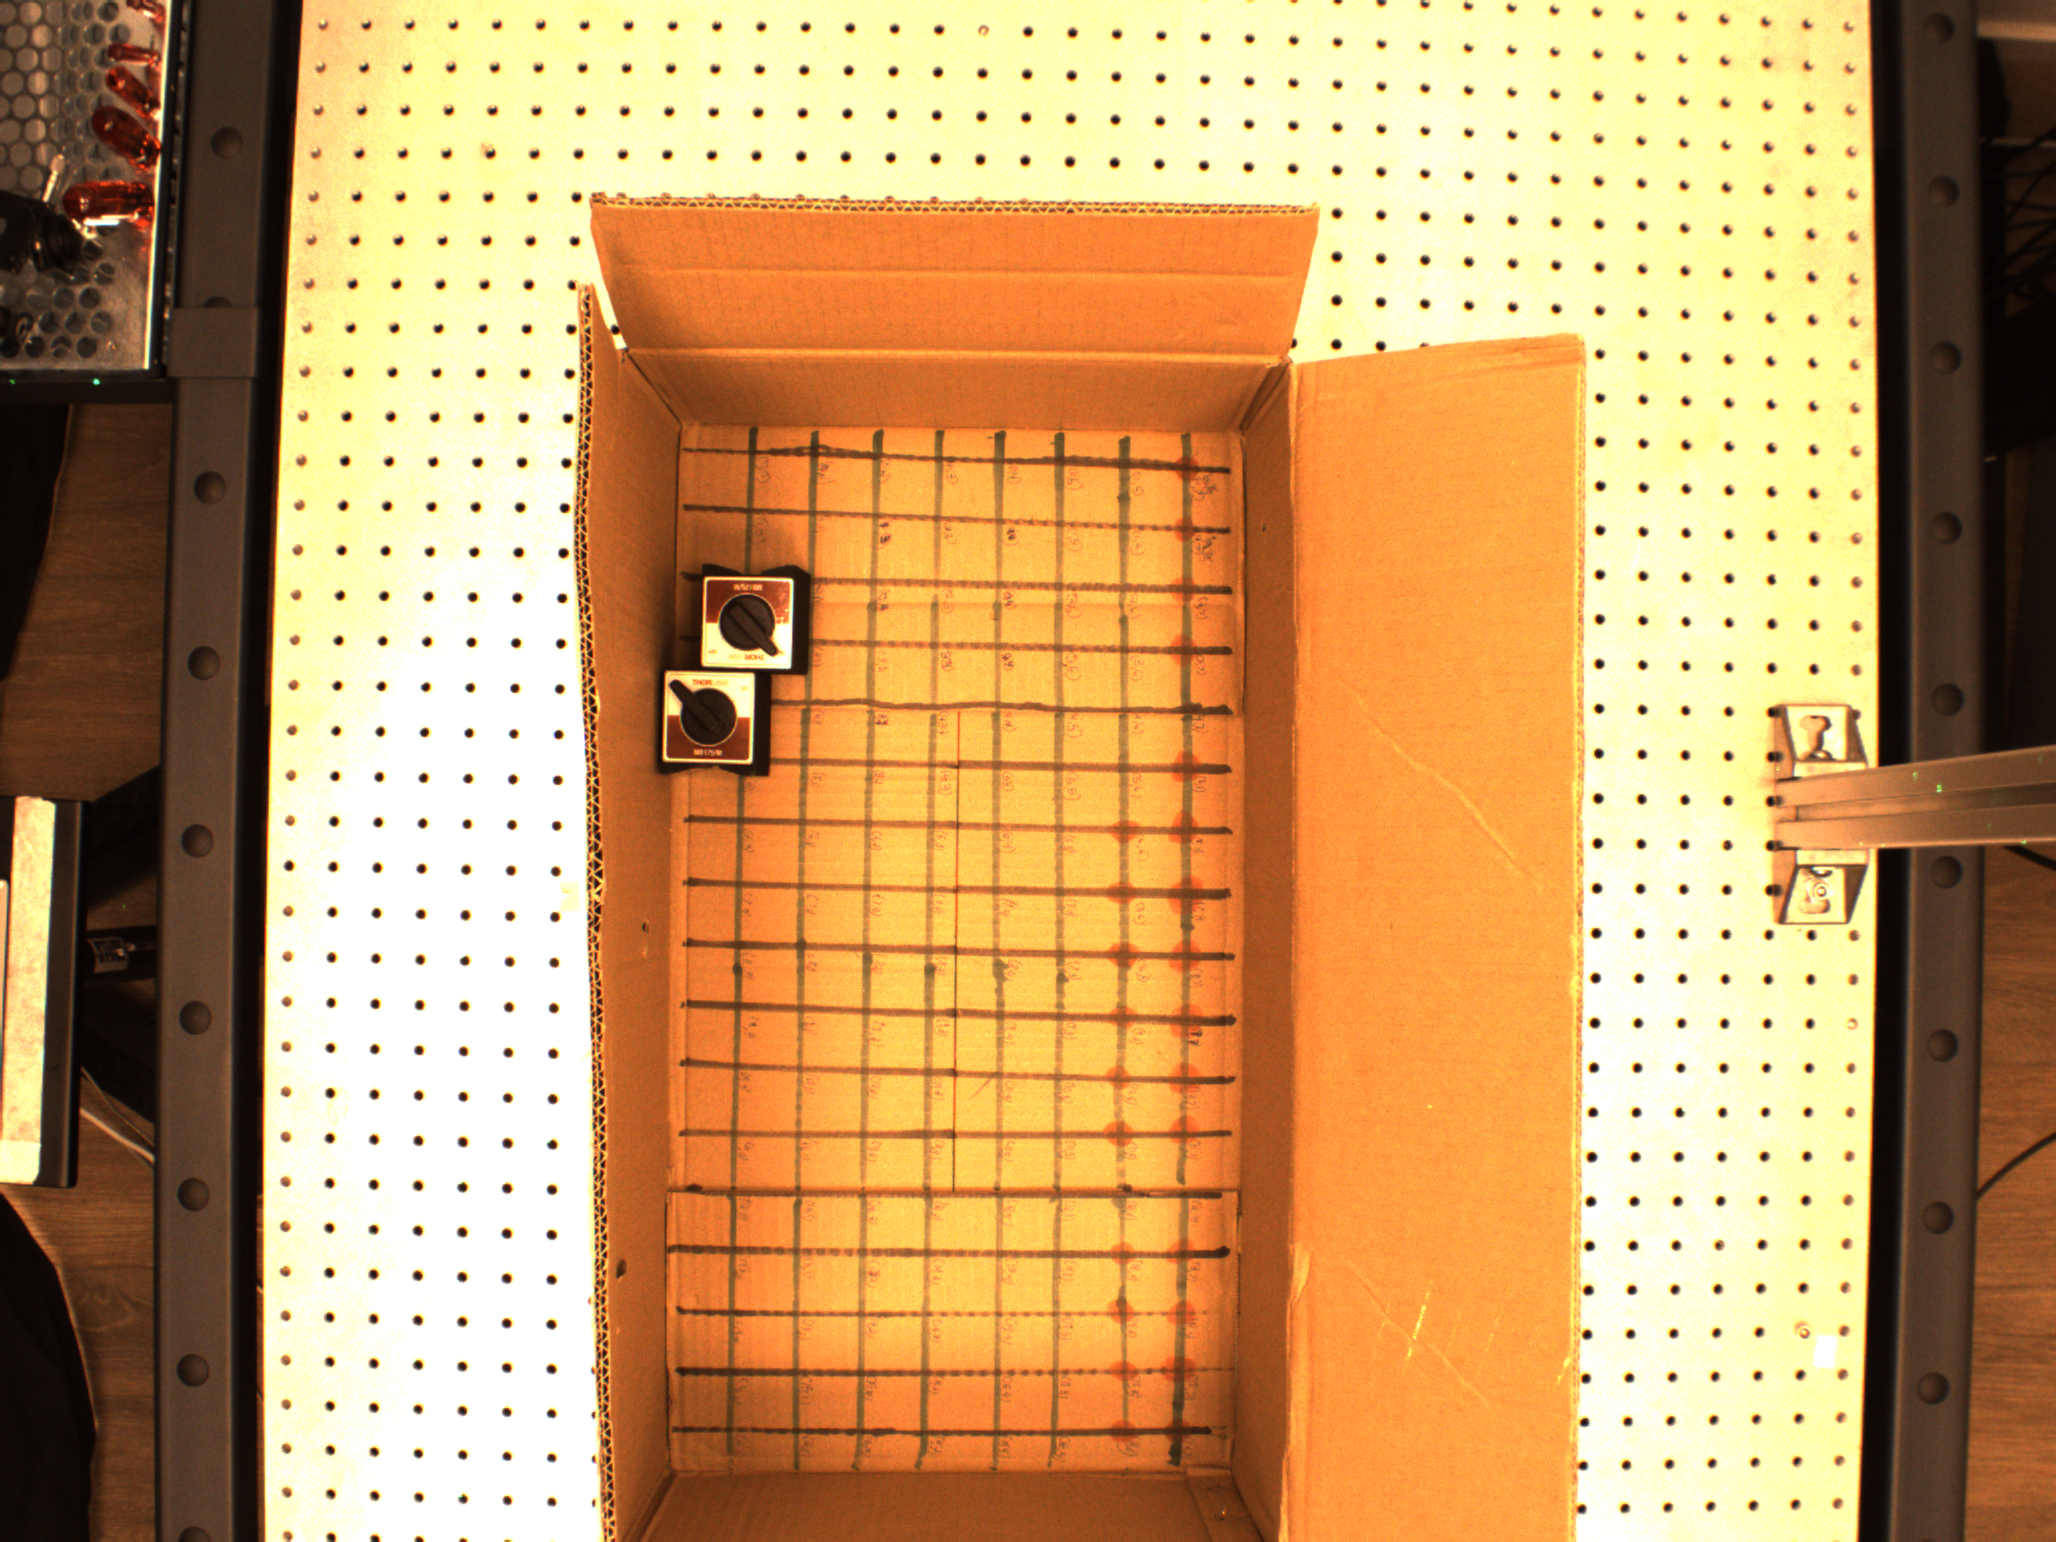

In [16]:
ds['train']['overhead_image'][0]

In [31]:
from huggingface_hub import HfApi

api = HfApi()
api.upload_folder(
    folder_path="test-data",
    repo_id="eturok-weizmann/laser-vibrations-test",
    repo_type="dataset",
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/eturok-weizmann/laser-vibrations-test/commit/a3f6d87d301ed0537ec29bb825d8014773e1c319', commit_message='Upload folder using huggingface_hub', commit_description='', oid='a3f6d87d301ed0537ec29bb825d8014773e1c319', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/eturok-weizmann/laser-vibrations-test', endpoint='https://huggingface.co', repo_type='dataset', repo_id='eturok-weizmann/laser-vibrations-test'), pr_revision=None, pr_num=None)

In [9]:
from huggingface_hub import HfApi, create_repo

api = HfApi()
REPO_ID = "eturok-weizmann/laser-vibrations-no-duplicates"

# Create repo if it doesn't exist
try:
    create_repo(REPO_ID, repo_type="dataset", exist_ok=True)
    print(f"Created/using repo: {REPO_ID}")
except Exception as e:
    print(f"Error creating repo: {e}")

# Upload folder
api.upload_folder(
    folder_path="test-data-shared",
    repo_id=REPO_ID,
    repo_type="dataset",
)

Created/using repo: eturok-weizmann/laser-vibrations-no-duplicates


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/eturok-weizmann/laser-vibrations-no-duplicates/commit/6018808e6650b84be98389717dc0931eef73686c', commit_message='Upload folder using huggingface_hub', commit_description='', oid='6018808e6650b84be98389717dc0931eef73686c', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/eturok-weizmann/laser-vibrations-no-duplicates', endpoint='https://huggingface.co', repo_type='dataset', repo_id='eturok-weizmann/laser-vibrations-no-duplicates'), pr_revision=None, pr_num=None)